In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam, RMSprop
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import RobustScaler #great
from sklearn.preprocessing import MinMaxScaler #not that great
from sklearn.preprocessing import StandardScaler #great
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping
from keras.callbacks import EarlyStopping
import itertools
import time
np.random.seed(42)

In [2]:
#Main dataframe
df = pd.read_csv("data_all_new.csv")
df['sprn_sq'] = df['SP500rn'] ** 2
df.head(2)

,Date,SP500,SP500rn,Nikkei,Nikkeirn,Gold,Goldrn,CAC40,CAC40rn,CrudeOil,...,oil_rn_spcor,daxrn_sq_spcor,FTSE100rn_sq_spcor,Torontorn_sq_spcor,VIXrn_sq_spcor,FTSEMIBrn_sq_spcor,RV_5_final,RV_10_final,RV_25_final,sprn_sq
0,2008-03-14 00:00:00,1288.14,-0.021002,122.79667,-0.001505,1002.5,0.008113,7184.87789,-0.003573,875.28782,...,-0.000472,-0.001297,-0.005631,-0.012616,-0.113066,-0.002597,0.029108,0.020876,0.016431,0.000441
1,2008-03-17 00:00:00,1276.60,-0.008999,121.35808,-0.011784,1002.3,-0.000200,6964.70867,-0.031123,861.95778,...,0.001681,-0.017385,-0.024142,-0.026512,-0.029090,-0.014613,0.026284,0.019560,0.015732,0.000081


In [3]:
joh = df.loc[:,('Date','sprn_sq', 'omega','alpha1','beta1','vol_fore','mu','RV_5_final','Nikkeirn_sq_spcor','CAC40rn_sq_spcor','daxrn_sq_spcor','FTSE100rn_sq_spcor','Torontorn_sq_spcor','FTSEMIBrn_sq_spcor')]
joh.head(2)

,Date,sprn_sq,omega,alpha1,beta1,vol_fore,mu,RV_5_final,Nikkeirn_sq_spcor,CAC40rn_sq_spcor,daxrn_sq_spcor,FTSE100rn_sq_spcor,Torontorn_sq_spcor,FTSEMIBrn_sq_spcor
0,2008-03-14 00:00:00,0.000441,7.740000e-07,0.052025,0.939504,0.014455,0.000361,0.029108,-0.000029,-0.001765,-0.001297,-0.005631,-0.012616,-0.002597
1,2008-03-17 00:00:00,0.000081,7.670000e-07,0.051834,0.939801,0.014263,0.000365,0.026284,-0.000283,-0.015345,-0.017385,-0.024142,-0.026512,-0.014613


In [4]:
train_df = joh.sort_values(by=['Date']).copy()
date_index = train_df.index

X = joh[['sprn_sq', 'omega','alpha1','beta1','vol_fore','mu','Nikkeirn_sq_spcor','CAC40rn_sq_spcor','daxrn_sq_spcor','FTSE100rn_sq_spcor','Torontorn_sq_spcor','FTSEMIBrn_sq_spcor']]
Y = joh['RV_5_final']

In [5]:
np.random.seed(42)

trainsplit=int(len(X)*0.80)

X_train = X.iloc[:trainsplit, :]
Y_train = Y.iloc[:trainsplit]
X_test = X.iloc[trainsplit:, :]
Y_test = Y.iloc[trainsplit:]

print(X.shape, X_train.shape, X_test.shape)
print(Y.shape, Y_train.shape, Y_test.shape)

(3701, 12) (2960, 12) (741, 12)
(3701,) (2960,) (741,)


In [6]:
#Scaling data
scalerX = MinMaxScaler()

X_train = scalerX.fit_transform(X_train)
X_test = scalerX.transform(X_test)

Y_train = Y_train.to_numpy().reshape(-1, 1)
Y_train = scalerX.fit_transform(Y_train)

Y_test = Y_test.to_numpy().reshape(-1, 1)
Y_test = scalerX.transform(Y_test)

print(X_train.shape, X_test.shape)
print(Y_train.shape, Y_test.shape)

(2960, 12) (741, 12)
(2960, 1) (741, 1)


In [7]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5)
np.random.seed(42)

In [8]:
#Defining my parameters
unit1 = 40
activation = 'relu'
dropout_rate = 0.1
opt = 'adam'
epochs = 64
batch_size = 32
reg_rate = 0.00001

In [9]:
np.random.seed(42)
from tensorflow.keras.regularizers import l1

#input
model = Sequential()
model.add(Dense(units=unit1, activation=activation, input_dim=X_train.shape[1], kernel_regularizer=l1(reg_rate)))
model.add(Dropout(dropout_rate))

#Output
model.add(Dense(units=1))

# Compiling the model
model.compile(optimizer=opt, loss='mean_squared_error')

2025-01-28 22:45:55.104066: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2025-01-28 22:45:55.104128: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2025-01-28 22:45:55.104149: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2025-01-28 22:45:55.104241: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-01-28 22:45:55.104275: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


2025-01-28 22:45:57.541562: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


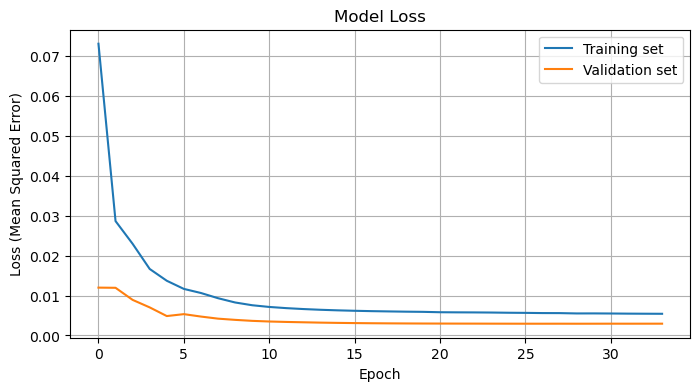

In [10]:
history = model.fit(
    X_train, Y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.1,
    shuffle=False,
    verbose=0,
    callbacks=[early_stopping]
)

# Plot training & validation loss values
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Training set')
plt.plot(history.history['val_loss'], label='Validation set')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (Mean Squared Error)')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

In [11]:
# Define the heteroscedasticity-adjusted error functions
def heteroscedasticity_adjusted_mse(y_true, y_pred):
    return np.mean((1 - (y_pred) / (y_true)) ** 2)

def heteroscedasticity_adjusted_mae(y_true, y_pred):
    return np.mean(np.abs(1 - (y_pred) / (y_true)))

# Initialize lists to store error metrics for each run
rmse_list = []
mae_list = []
hmse_list = []
hmae_list = []

# Run the model 25 times
for i in range(25):
    print(f"Run {i+1}/25")
    # Train the model
    history = model.fit(
        X_train, Y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.1,
        shuffle=False,
        verbose=0,
        callbacks=[early_stopping]
    )

    # Predict on the test set
    y_pred = model.predict(X_test).flatten()

    # Calculate error metrics
    rmse = np.sqrt(mean_squared_error(Y_test, y_pred))
    mae = mean_absolute_error(Y_test, y_pred)
    hmse = heteroscedasticity_adjusted_mse(Y_test, y_pred)
    hmae = heteroscedasticity_adjusted_mae(Y_test, y_pred)

    # Append to lists
    rmse_list.append(rmse)
    mae_list.append(mae)
    hmse_list.append(hmse)
    hmae_list.append(hmae)

# Compute the average of each metric
average_rmse = np.mean(rmse_list)
average_mae = np.mean(mae_list)
average_hmse = np.mean(hmse_list)
average_hmae = np.mean(hmae_list)

# Print the results rounded to 6 decimal places
print(f"Average RMSE: {average_rmse:.6f}")
print(f"Average MAE: {average_mae:.6f}")
print(f"Average HMSE: {average_hmse:.6f}")
print(f"Average HMAE: {average_hmae:.6f}")


Run 1/25
24/24 [==============================] - 15s 544ms/step
Run 2/25
24/24 [==============================] - 1s 41ms/step
Run 3/25
24/24 [==============================] - 1s 28ms/step
Run 4/25
24/24 [==============================] - 0s 8ms/step
Run 5/25
24/24 [==============================] - 1s 16ms/step
Run 6/25
24/24 [==============================] - 1s 20ms/step
Run 7/25
24/24 [==============================] - 1s 36ms/step
Run 8/25
24/24 [==============================] - 1s 15ms/step
Run 9/25
24/24 [==============================] - 0s 5ms/step
Run 10/25
24/24 [==============================] - 1s 45ms/step
Run 11/25
24/24 [==============================] - 1s 31ms/step
Run 12/25
24/24 [==============================] - 1s 28ms/step
Run 13/25
24/24 [==============================] - 1s 23ms/step
Run 14/25
24/24 [==============================] - 1s 23ms/step
Run 15/25
24/24 [==============================] - 1s 33ms/step
Run 16/25
24/24 [==============================] 

In [12]:
from scipy.stats import pearsonr
Y_test = Y_test.flatten()
corr_testing = pearsonr(y_pred, Y_test)
corr_testing

PearsonRResult(statistic=0.8221959835111902, pvalue=4.96030205231812e-183)

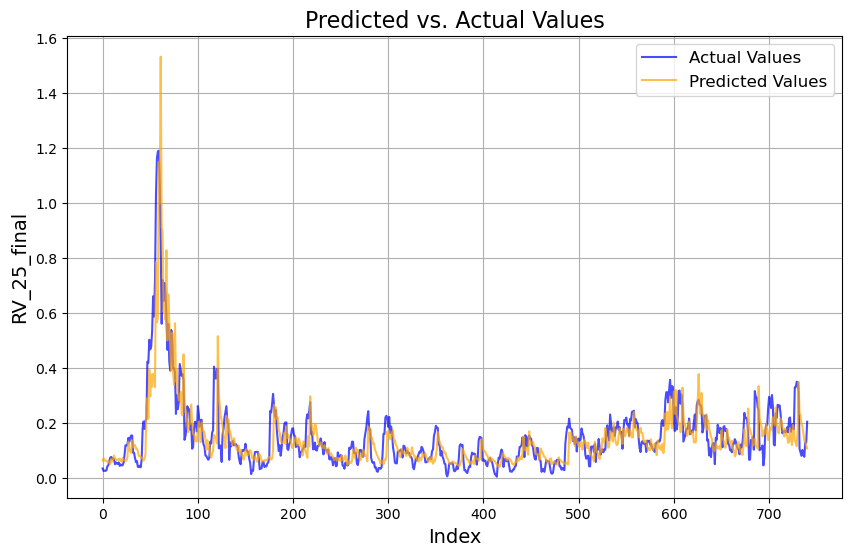

In [13]:
plt.figure(figsize=(10, 6))
plt.plot(Y_test, label="Actual Values", linestyle='-', color='blue', alpha=0.7)
plt.plot(y_pred, label="Predicted Values", linestyle='-', color='orange', alpha=0.7)
plt.title("Predicted vs. Actual Values", fontsize=16)
plt.xlabel("Index", fontsize=14)
plt.ylabel("RV_25_final", fontsize=14)
plt.legend(loc="upper right", fontsize=12)
plt.grid(True)
plt.show()

/Users/roselinekolony/anaconda3/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
python(7828) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


1/1 [==============================] - 0s 179ms/step


python(7830) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
  0%|                                                   | 0/400 [00:00<?, ?it/s]

1295/1295 [==============================] - 3s 2ms/step


  0%|                                           | 1/400 [00:04<31:29,  4.74s/it]

...

100%|████████████████████████████████████████▊| 398/400 [32:05<00:09,  4.95s/it]

1295/1295 [==============================] - 5s 3ms/step


100%|████████████████████████████████████████▉| 399/400 [32:11<00:05,  5.14s/it]

1295/1295 [==============================] - 4s 3ms/step


100%|█████████████████████████████████████████| 400/400 [32:16<00:00,  4.84s/it]


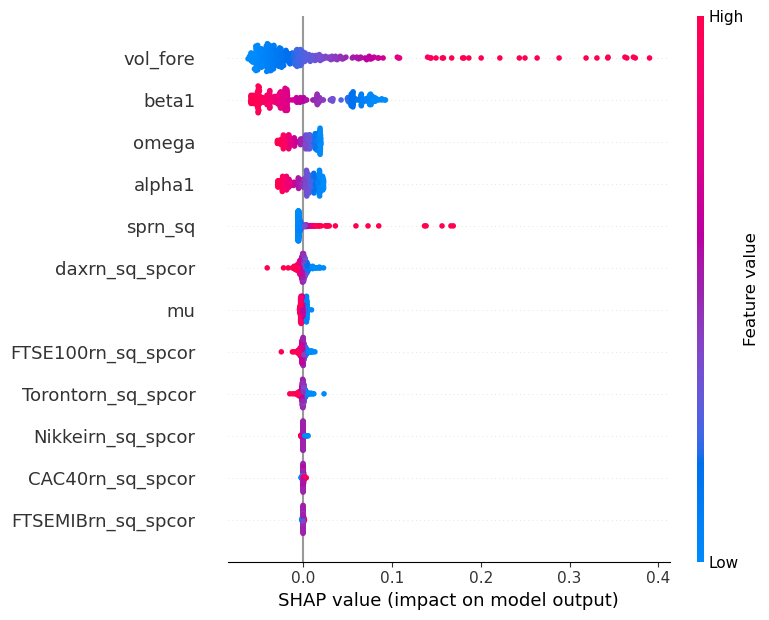

In [14]:
import shap

feature_names = X.columns.tolist()

# SHAP expects model functions to take a 2D numpy array as input, so we define a wrapper function around the original Keras predict function.
def f_wrapper(X):
    return model.predict(X).flatten()

# Too many input data - use a random slice
# Summarize with weighted kmeans
X_train_summary = shap.kmeans(X_train, 20)

# Compute SHAP values
explainer = shap.KernelExplainer(f_wrapper, shap.kmeans(X_train, 20), feature_names=feature_names)

# Sampling 400 rows from X_train
# Use numpy to randomly select indices
sample_indices = np.random.choice(X_train.shape[0], size=400, replace=False)
X_train_sample = X_train[sample_indices]

# Compute SHAP values for the sampled data
shap_values = explainer.shap_values(X_train_sample)
shap.summary_plot(shap_values, X_train_sample, feature_names=feature_names)